# SVM vs QKSVM — Comparación

Este notebook carga los resultados precomputados de:
- `../classical/svm_results.json`
- `../quantum/qksvm_results.json`

y genera todas las gráficas de comparación y la tabla resumen.

**No se entrena ningún modelo aquí.** Se puede re-ejecutar libremente sin tocar los notebooks de entrenamiento.

Activa `COMPARE_4F = True` cuando los archivos de resultados de 4 características también estén disponibles.

## Importaciones

In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Configuración

In [2]:
COMPARE_4F = True

SVM_FILE      = "../classical/svm_results.json"
QKSVM_FILE    = "../quantum/qksvm_results.json"
SVM_4F_FILE   = "../classical/svm_results_4f.json"
QKSVM_4F_FILE = "../quantum/qksvm_results_4f.json"

for f in [SVM_FILE, QKSVM_FILE]:
    if not os.path.exists(f):
        raise FileNotFoundError(
            f"Missing results file: {f}\n"
            "Run svm.ipynb and qksvm.ipynb first."
        )

if COMPARE_4F:
    for f in [SVM_4F_FILE, QKSVM_4F_FILE]:
        if not os.path.exists(f):
            raise FileNotFoundError(f"Missing 4-feature results file: {f}")

print("Results files found — ready to compare.")


Results files found — ready to compare.


## Cargar Resultados

In [3]:
with open(SVM_FILE) as f:
    svm = json.load(f)

with open(QKSVM_FILE) as f:
    qksvm = json.load(f)

if COMPARE_4F:
    with open(SVM_4F_FILE) as f:
        svm4 = json.load(f)
    with open(QKSVM_4F_FILE) as f:
        qksvm4 = json.load(f)

print("SVM results:")
print(f"  Test accuracy : {svm['accuracy_test']:.4f}")
print(f"  Train time    : {svm['train_time_s']:.4f} s")
print()
print("QKSVM results:")
print(f"  Test accuracy (sim)  : {qksvm['accuracy_test_sim']:.4f}")
print(f"  Kernel compute time  : {qksvm['total_kernel_time_s']:.2f} s")
print(f"  SVM train time       : {qksvm['svm_train_time_s']:.4f} s")
print(f"  Total time           : {qksvm['total_time_s']:.2f} s")
if qksvm.get("real_hw_run"):
    print(f"  Real HW backend      : {qksvm.get('backend_name')}")
    if qksvm.get("kernel_corr_sim_real") is not None:
        print(f"  Kernel Pearson r     : {qksvm['kernel_corr_sim_real']:.4f}")
        print(f"  Kernel MAE           : {qksvm['kernel_mae_sim_real']:.4f}")

SVM results:
  Test accuracy : 0.8500
  Train time    : 0.0016 s

QKSVM results:
  Test accuracy (sim)  : 0.6000
  Kernel compute time  : 20.46 s
  SVM train time       : 0.0023 s
  Total time           : 20.47 s
  Real HW backend      : ibm_fez
  Kernel Pearson r     : 0.9738
  Kernel MAE           : 0.0614


## Gráfica 1 — Comparación de Precisión

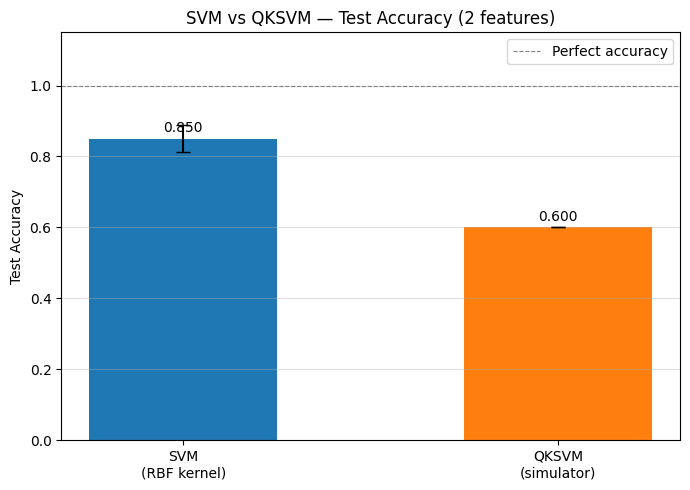

In [4]:
labels = ["SVM\n(kernel RBF)", "QKSVM\n(simulador)"]
values = [svm["accuracy_test"], qksvm["accuracy_test_sim"]]
colors = ["tab:blue", "tab:orange"]
yerr   = [svm["cv_std"], 0]

if qksvm.get("real_hw_run") and qksvm.get("accuracy_test_real") is not None:
    labels.append("QKSVM\n(hardware real)")
    values.append(qksvm["accuracy_test_real"])
    colors.append("tab:red")
    yerr.append(0)

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(x, values, color=colors, width=0.5,
              yerr=yerr, capsize=5, error_kw={"elinewidth": 1.5})

for bar, val, err in zip(bars, values, yerr):
    ax.text(bar.get_x() + bar.get_width() / 2, val + err + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Precisión en test")
ax.set_title(f"SVM vs QKSVM — Precisión en test ({svm['n_features']} características)")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="Precisión perfecta")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("plot1_accuracy.png", dpi=150)
plt.show()

## Gráfica 2 — Desglose de Tiempo

Para el QKSVM, el tiempo total se divide en dos componentes: cálculo del kernel (cuántico)
y entrenamiento del SVM (clásico). Este desglose muestra dónde se concentra realmente el coste.

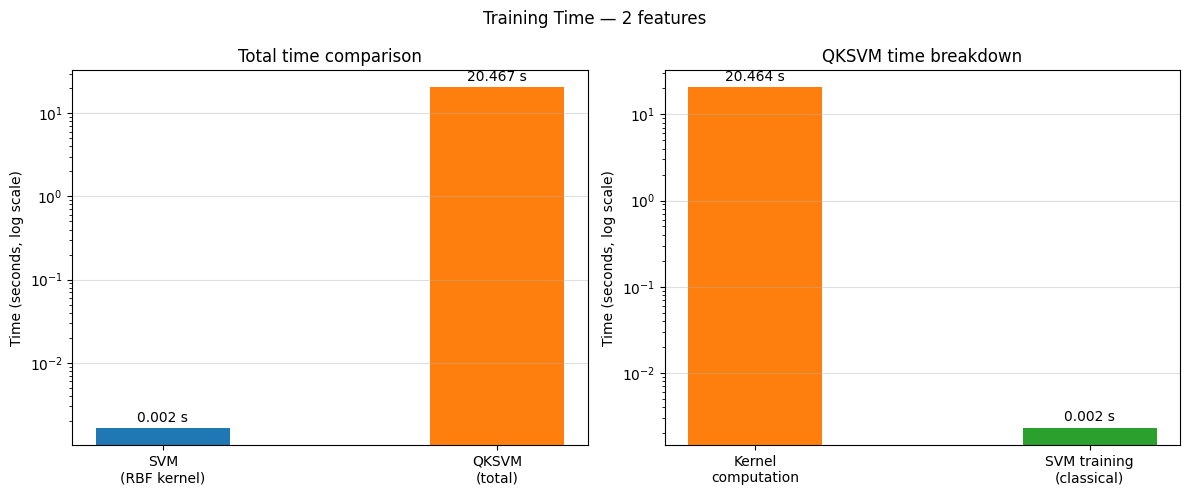

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: total training time comparison
t_labels = ["SVM\n(kernel RBF)", "QKSVM\n(total)"]
t_values = [svm["train_time_s"], qksvm["total_time_s"]]
t_colors = ["tab:blue", "tab:orange"]

bars = axes[0].bar(t_labels, t_values, color=t_colors, width=0.4)
for bar, val in zip(bars, t_values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val * 1.1,
                 f"{val:.3f} s", ha="center", va="bottom", fontsize=10)
axes[0].set_yscale("log")
axes[0].set_ylabel("Tiempo (segundos, escala log)")
axes[0].set_title("Comparación de tiempo total")
axes[0].grid(axis="y", alpha=0.4)

# Right: QKSVM time breakdown (kernel vs SVM)
breakdown_labels = ["Cálculo del\nkernel", "Entrenamiento\nSVM (clásico)"]
breakdown_values = [qksvm["total_kernel_time_s"], qksvm["svm_train_time_s"]]
breakdown_colors = ["tab:orange", "tab:green"]

bars2 = axes[1].bar(breakdown_labels, breakdown_values, color=breakdown_colors, width=0.4)
for bar, val in zip(bars2, breakdown_values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val * 1.1,
                 f"{val:.3f} s", ha="center", va="bottom", fontsize=10)
axes[1].set_yscale("log")
axes[1].set_ylabel("Tiempo (segundos, escala log)")
axes[1].set_title("Desglose de tiempo del QKSVM")
axes[1].grid(axis="y", alpha=0.4)

plt.suptitle(f"Tiempo de entrenamiento — {svm['n_features']} características")
plt.tight_layout()
plt.savefig("plot2_time_breakdown.png", dpi=150)
plt.show()

## Gráfica 3 — Matrices de Confusión

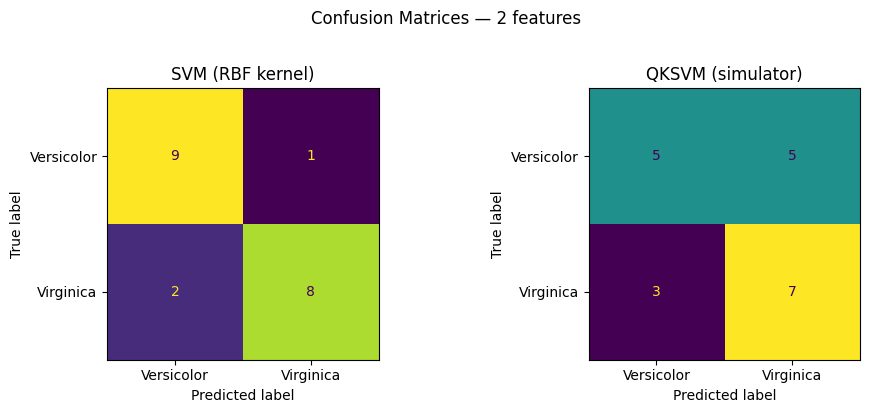

In [6]:
cm_svm   = confusion_matrix(svm["y_test"],   svm["y_pred_test"])
cm_qksvm = confusion_matrix(qksvm["y_test"], qksvm["y_pred_test_sim"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, cm, title in zip(axes,
                          [cm_svm, cm_qksvm],
                          ["SVM (kernel RBF)", "QKSVM (simulador)"]):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=["Versicolor", "Virginica"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.suptitle(f"Matrices de confusión — {svm['n_features']} características", y=1.02)
plt.tight_layout()
plt.savefig("plot3_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## Gráfica 4 — Comparación 2 vs 4 Características (opcional)

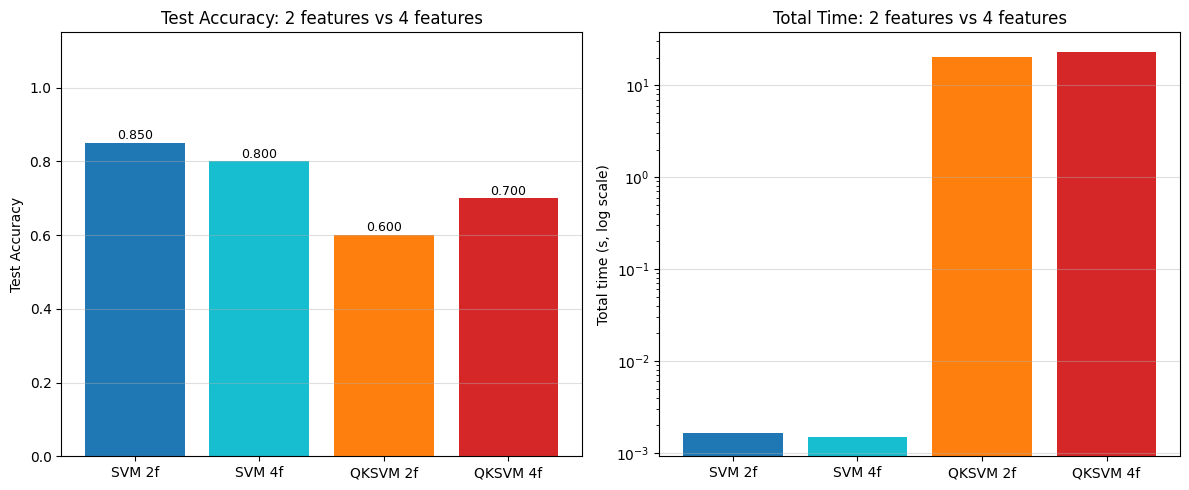

In [7]:
if COMPARE_4F:
    experiments = [
        ("SVM 2f",   svm["accuracy_test"],      svm["train_time_s"],      "tab:blue"),
        ("SVM 4f",   svm4["accuracy_test"],     svm4["train_time_s"],     "tab:cyan"),
        ("QKSVM 2f", qksvm["accuracy_test_sim"], qksvm["total_time_s"],   "tab:orange"),
        ("QKSVM 4f", qksvm4["accuracy_test_sim"],qksvm4["total_time_s"],  "tab:red"),
    ]

    names  = [e[0] for e in experiments]
    accs   = [e[1] for e in experiments]
    times  = [e[2] for e in experiments]
    colors = [e[3] for e in experiments]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].bar(names, accs, color=colors)
    for i, val in enumerate(accs):
        axes[0].text(i, val + 0.01, f"{val:.3f}", ha="center", fontsize=9)
    axes[0].set_ylim(0, 1.15)
    axes[0].set_ylabel("Precisión en test")
    axes[0].set_title("Precisión en test: 2 vs 4 características")
    axes[0].grid(axis="y", alpha=0.4)

    axes[1].bar(names, times, color=colors)
    axes[1].set_yscale("log")
    axes[1].set_ylabel("Tiempo total (s, escala log)")
    axes[1].set_title("Tiempo total: 2 vs 4 características")
    axes[1].grid(axis="y", alpha=0.4)

    plt.tight_layout()
    plt.savefig("plot4_2f_vs_4f.png", dpi=150)
    plt.show()
else:
    print("COMPARE_4F is False — skipping 2f vs 4f comparison.")
    print("Set COMPARE_4F = True once both 4-feature result files are available.")

## Gráfica 5 — Análisis de Ruido del Kernel (Hardware Real)

Diagrama de dispersión de los 100 valores del kernel calculados en el simulador Aer frente a IBM Quantum hardware
para el subconjunto demo de 10 puntos (5 por clase). Los puntos sobre la diagonal (y = x) indican acuerdo perfecto.
El histograma muestra la distribución de errores (real − sim) para todas las entradas del kernel.

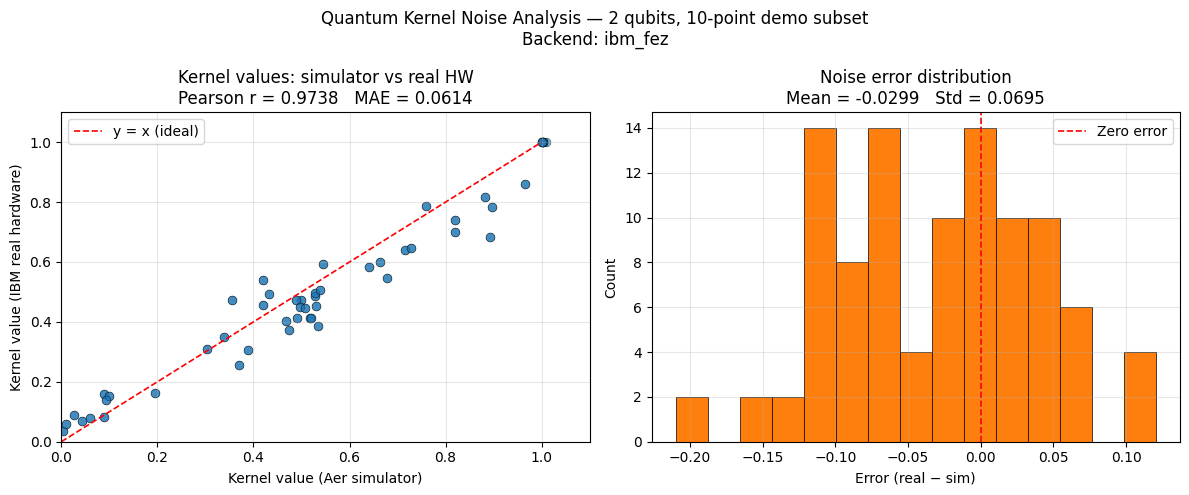

In [8]:
if qksvm.get("real_hw_run") and qksvm.get("K_demo_sim") is not None:
    K_sim  = np.array(qksvm["K_demo_sim"]).ravel()
    K_real = np.array(qksvm["K_demo_real"]).ravel()
    r      = qksvm["kernel_corr_sim_real"]
    mae    = qksvm["kernel_mae_sim_real"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Left: scatter sim vs real
    axes[0].scatter(K_sim, K_real, alpha=0.6, edgecolors="k", linewidths=0.4, s=40)
    axes[0].plot([0, 1], [0, 1], "r--", linewidth=1.2, label="y = x (ideal)")  # label same in Spanish
    axes[0].set_xlabel("Valor del kernel (simulador Aer)")
    axes[0].set_ylabel("Valor del kernel (hardware IBM real)")
    axes[0].set_xlim(0, 1.1)
    axes[0].set_ylim(0, 1.1)
    axes[0].set_title(f"Valores del kernel: simulador vs hardware real\nPearson r = {r:.4f}   MAE = {mae:.4f}")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Right: error distribution
    errors = K_real - K_sim
    axes[1].hist(errors, bins=15, color="tab:orange", edgecolor="k", linewidth=0.5)
    axes[1].axvline(0, color="red", linestyle="--", linewidth=1.2, label="Error cero")
    axes[1].set_xlabel("Error (real − sim)")  # same in Spanish
    axes[1].set_ylabel("Frecuencia")
    axes[1].set_title(f"Distribución del error de ruido\nMedia = {errors.mean():.4f}   Desv. típica = {errors.std():.4f}")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle(
        f"Análisis de Ruido del Kernel Cuántico — {qksvm['n_qubits']} qubits, "
        f"subconjunto demo de {qksvm.get('kernel_demo_n', 10)} puntos\n"
        f"Backend: {qksvm.get('backend_name', 'N/A')}"
    )
    plt.tight_layout()
    plt.savefig("plot5_kernel_noise.png", dpi=150)
    plt.show()
else:
    print("Plot 5 skipped — no real hardware kernel data available.")

## Tabla Resumen

In [9]:
summary = {
    "n_features"                  : svm["n_features"],
    "n_train"                     : svm["n_train"],
    "n_test"                      : svm["n_test"],
    # SVM
    "svm_accuracy_test"           : svm["accuracy_test"],
    "svm_cv_mean"                 : svm["cv_mean"],
    "svm_cv_std"                  : svm["cv_std"],
    "svm_train_time_s"            : svm["train_time_s"],
    "svm_n_support_vectors"       : svm["n_support_vectors"],
    # QKSVM (simulator)
    "qksvm_accuracy_test_sim"     : qksvm["accuracy_test_sim"],
    "qksvm_kernel_train_time_s"   : qksvm["kernel_train_time_s"],
    "qksvm_kernel_test_time_s"    : qksvm["kernel_test_time_s"],
    "qksvm_svm_train_time_s"      : qksvm["svm_train_time_s"],
    "qksvm_total_time_s"          : qksvm["total_time_s"],
    "qksvm_n_qubits"              : qksvm["n_qubits"],
    "qksvm_n_trainable_params"    : qksvm["n_trainable_params"],
    "qksvm_n_support_vectors"     : qksvm["n_support_vectors"],
    # QKSVM (real hardware — kernel noise demo)
    "qksvm_real_hw_run"           : qksvm.get("real_hw_run", False),
    "qksvm_backend"               : qksvm.get("backend_name"),
    "qksvm_kernel_demo_n"         : qksvm.get("kernel_demo_n"),
    "qksvm_kernel_real_time_s"    : qksvm.get("kernel_real_time_s"),
    "qksvm_kernel_corr_sim_real"  : qksvm.get("kernel_corr_sim_real"),
    "qksvm_kernel_mae_sim_real"   : qksvm.get("kernel_mae_sim_real"),
}

if COMPARE_4F:
    summary["svm_4f_accuracy_test"]       = svm4["accuracy_test"]
    summary["svm_4f_train_time_s"]        = svm4["train_time_s"]
    summary["qksvm_4f_accuracy_test_sim"] = qksvm4["accuracy_test_sim"]
    summary["qksvm_4f_total_time_s"]      = qksvm4["total_time_s"]

with open("comparison_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

# Print as readable table
col_w = 32
print(f"{'Metric':<{col_w}} {'SVM':>14} {'QKSVM (sim)':>14} {'QKSVM (real HW)':>16}")
print("-" * (col_w + 48))

r_str   = f"{qksvm['kernel_corr_sim_real']:.4f}" if qksvm.get("kernel_corr_sim_real") else "N/A"
mae_str = f"{qksvm['kernel_mae_sim_real']:.4f}"  if qksvm.get("kernel_mae_sim_real")  else "N/A"
t_real  = f"{qksvm['kernel_real_time_s']:.2f} s" if qksvm.get("kernel_real_time_s")   else "N/A"

rows = [
    ("Test accuracy",
     f"{svm['accuracy_test']:.4f}",
     f"{qksvm['accuracy_test_sim']:.4f}",
     "— (demo only)"),
    ("Train accuracy",
     f"{svm['accuracy_train']:.4f}",
     f"{qksvm['accuracy_train_sim']:.4f}",
     "N/A"),
    ("CV mean ± std",
     f"{svm['cv_mean']:.4f} ± {svm['cv_std']:.4f}",
     "N/A", "N/A"),
    ("Kernel Pearson r (sim vs real)",
     "N/A", "N/A", r_str),
    ("Kernel MAE (sim vs real)",
     "N/A", "N/A", mae_str),
    ("Kernel compute time",
     "—",
     f"{qksvm['total_kernel_time_s']:.2f} s",
     t_real),
    ("SVM train time",
     f"{svm['train_time_s']:.4f} s",
     f"{qksvm['svm_train_time_s']:.4f} s",
     "—"),
    ("Total time",
     f"{svm['train_time_s']:.4f} s",
     f"{qksvm['total_time_s']:.2f} s",
     "N/A"),
    ("Support vectors",
     str(svm['n_support_vectors']),
     str(qksvm['n_support_vectors']),
     "—"),
]

for label, sv, qk, qr in rows:
    print(f"{label:<{col_w}} {sv:>14} {qk:>14} {qr:>16}")

print()
print("Summary saved to comparison_summary.json")

Metric                                      SVM    QKSVM (sim)  QKSVM (real HW)
--------------------------------------------------------------------------------
Test accuracy                            0.8500         0.6000    — (demo only)
Train accuracy                           0.9750         0.8375              N/A
CV mean ± std                    0.9400 ± 0.0374            N/A              N/A
Kernel Pearson r (sim vs real)              N/A            N/A           0.9738
Kernel MAE (sim vs real)                    N/A            N/A           0.0614
Kernel compute time                           —        20.46 s          61.54 s
SVM train time                         0.0016 s       0.0023 s                —
Total time                             0.0016 s        20.47 s              N/A
Support vectors                              17             47                —

Summary saved to comparison_summary.json
